Dataset Training No. 1

In [12]:
import kagglehub


path = kagglehub.dataset_download("manjilkarki/deepfake-and-real-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'deepfake-and-real-images' dataset.
Path to dataset files: /kaggle/input/deepfake-and-real-images


In [18]:
!cp -r /kaggle/input/deepfake-and-real-images/Dataset /content/

In [14]:
!pip install timm

import os
import json
import hashlib
import random
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
from google.colab import drive

In [19]:
DATASET_PATH = "/content/Dataset"

In [20]:
def compute_hash(file_path):
    with open(file_path, "rb") as f:
        return hashlib.sha256(f.read()).hexdigest()

def generate_metadata(image_path):
    metadata = {
        "hash": compute_hash(image_path),
        "timestamp": datetime.now().isoformat(),
        "device_id": hashlib.sha256(b"device_01").hexdigest()[:16]
    }
    with open(image_path + ".json", "w") as f:
        json.dump(metadata, f)

for split in ["Train", "Validation", "Test"]:
    for label in ["Fake", "Real"]:
        folder = os.path.join(DATASET_PATH, split, label)
        for file in os.listdir(folder):
            if file.lower().endswith((".jpg", ".png", ".jpeg")):
                generate_metadata(os.path.join(folder, file))

print("Provenance metadata created.")

Provenance metadata created.


In [21]:
def remove_random_metadata(folder, percentage=0.2):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    remove_count = int(len(files) * percentage)
    for f in random.sample(files, remove_count):
        os.remove(os.path.join(folder, f))

def forge_random_metadata(folder, percentage=0.1):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    forge_count = int(len(files) * percentage)
    for f in random.sample(files, forge_count):
        path = os.path.join(folder, f)
        with open(path, "r") as file:
            metadata = json.load(file)
        metadata["hash"] = "FORGED_HASH"
        with open(path, "w") as file:
            json.dump(metadata, file)

for label in ["Fake", "Real"]:
    folder = os.path.join(DATASET_PATH, "Test", label)
    remove_random_metadata(folder, 0.2)
    forge_random_metadata(folder, 0.1)

print("Provenance manipulation simulated.")

Provenance manipulation simulated.


In [22]:
def verify_provenance(image_path):
    metadata_path = image_path + ".json"

    if not os.path.exists(metadata_path):
        return "missing"

    with open(metadata_path, "r") as f:
        metadata = json.load(f)

    if metadata["hash"] != compute_hash(image_path):
        return "forged"

    return "valid"

In [23]:
IMG_SIZE = 224
BATCH_SIZE = 2

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, "Train"), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, "Validation"), transform=transform)
test_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, "Test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model('efficientnet_b0', pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [25]:
from tqdm import tqdm

EPOCHS = 1

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

Epoch [1/1]: 100%|██████████| 70001/70001 [47:38<00:00, 24.49it/s, loss=0.00152]

Epoch 1 Loss: 0.0826


In [26]:
model.eval()

all_probs = []
all_labels = []
all_preds = []
all_paths = []

with torch.no_grad():
    for i, (images, labels) in enumerate(test_loader):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:,1]

        for j in range(len(probs)):
            idx = i * BATCH_SIZE + j
            image_path = test_dataset.samples[idx][0]

            provenance_status = verify_provenance(image_path)
            model_score = probs[j].item()

            if provenance_status == "valid":
                adjustment = 0
            elif provenance_status == "missing":
                adjustment = 0.15
            elif provenance_status == "forged":
                adjustment = 0.35

            final_score = min(model_score + adjustment, 1.0)
            prediction = 1 if final_score > 0.5 else 0

            all_probs.append(final_score)
            all_labels.append(labels[j].item())
            all_preds.append(prediction)
            all_paths.append(image_path)

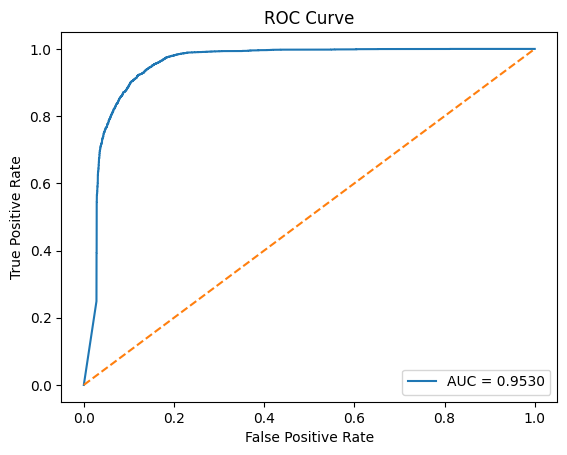

AUC Score: 0.9529685555087164


In [27]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

In [28]:
report = classification_report(all_labels, all_preds, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.to_csv("classification_report.csv")
df_report

,precision,recall,f1-score,support
0,0.987284,0.749272,0.851967,5492.000000
1,0.795606,0.990209,0.882305,5413.000000
accuracy,0.868867,0.868867,0.868867,0.868867
macro avg,0.891445,0.869740,0.867136,10905.000000
weighted avg,0.892140,0.868867,0.867026,10905.000000


In [29]:
cm = confusion_matrix(all_labels, all_preds)
df_cm = pd.DataFrame(cm,
                     columns=["Pred Real", "Pred Fake"],
                     index=["Actual Real", "Actual Fake"])
df_cm.to_csv("confusion_matrix.csv")
df_cm

,Pred Real,Pred Fake
Actual Real,4115,1377
Actual Fake,53,5360


In [30]:
results_df = pd.DataFrame({
    "Image_Path": all_paths,
    "True_Label": all_labels,
    "Predicted_Label": all_preds,
    "Hybrid_Score": all_probs
})

results_df.to_csv("detailed_results.csv")
results_df.head()

,Image_Path,True_Label,Predicted_Label,Hybrid_Score
0,/content/Dataset/Test/Fake/fake_0.jpg,0,0,0.007853
1,/content/Dataset/Test/Fake/fake_1.jpg,0,0,0.227592
2,/content/Dataset/Test/Fake/fake_10.jpg,0,0,0.005086
3,/content/Dataset/Test/Fake/fake_100.jpg,0,0,0.054841
4,/content/Dataset/Test/Fake/fake_1000.jpg,0,0,0.005074


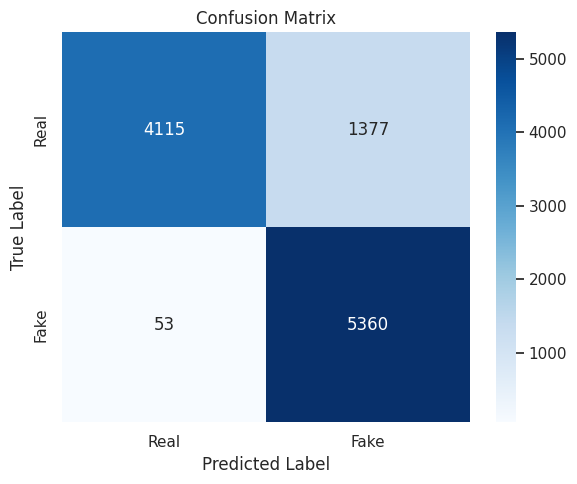

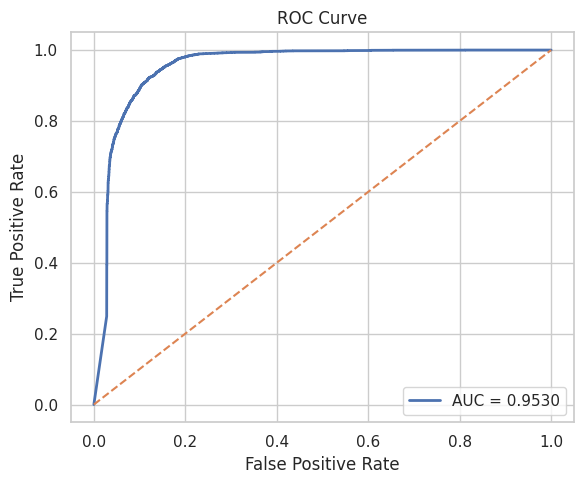

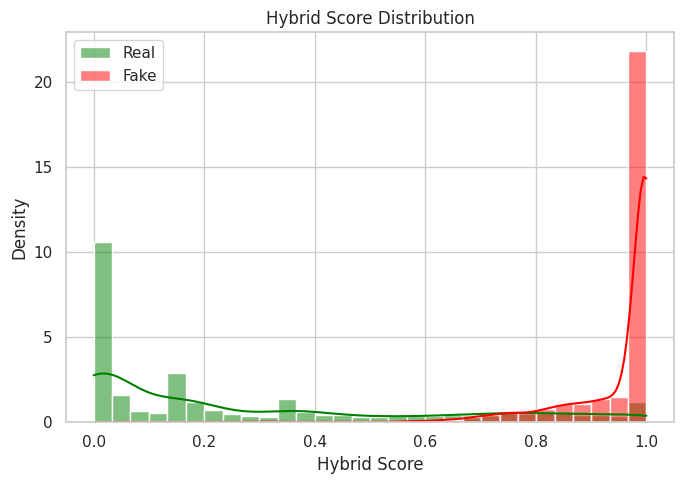

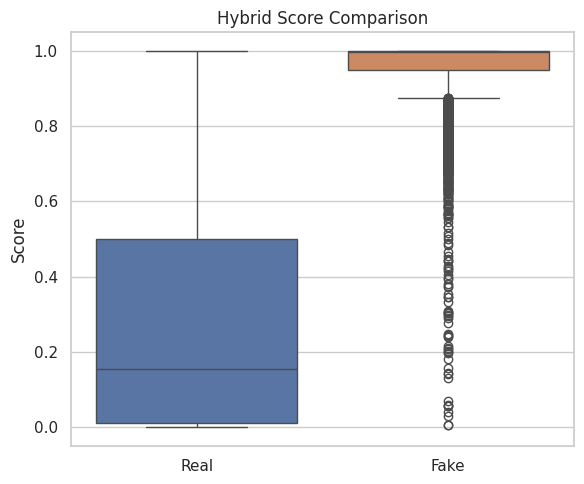


FINAL PERFORMANCE SUMMARY
Accuracy: 0.8689
AUC Score: 0.9530
Total Samples: 10905


In [31]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

sns.set_theme(style="whitegrid")


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix_visual.png", dpi=300)
plt.show()




fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_visual.png", dpi=300)
plt.show()




real_scores = [all_probs[i] for i in range(len(all_labels)) if all_labels[i] == 0]
fake_scores = [all_probs[i] for i in range(len(all_labels)) if all_labels[i] == 1]

plt.figure(figsize=(7,5))
sns.histplot(real_scores, color="green", label="Real", kde=True, stat="density", bins=30)
sns.histplot(fake_scores, color="red", label="Fake", kde=True, stat="density", bins=30)
plt.legend()
plt.title("Hybrid Score Distribution")
plt.xlabel("Hybrid Score")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("score_distribution.png", dpi=300)
plt.show()




plt.figure(figsize=(6,5))
sns.boxplot(data=[real_scores, fake_scores])
plt.xticks([0,1], ["Real", "Fake"])
plt.title("Hybrid Score Comparison")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("score_boxplot.png", dpi=300)
plt.show()




accuracy = np.mean(np.array(all_labels) == np.array(all_preds))

print("\n====================================")
print("FINAL PERFORMANCE SUMMARY")
print("====================================")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC Score: {roc_auc:.4f}")
print(f"Total Samples: {len(all_labels)}")
print("====================================")



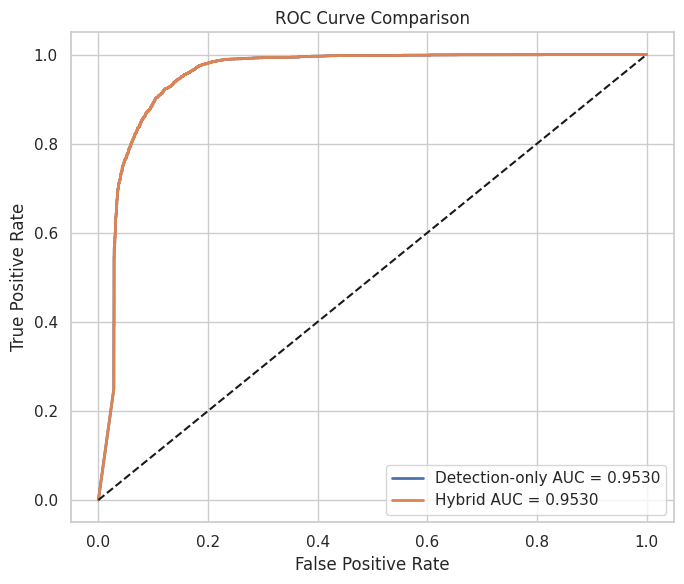

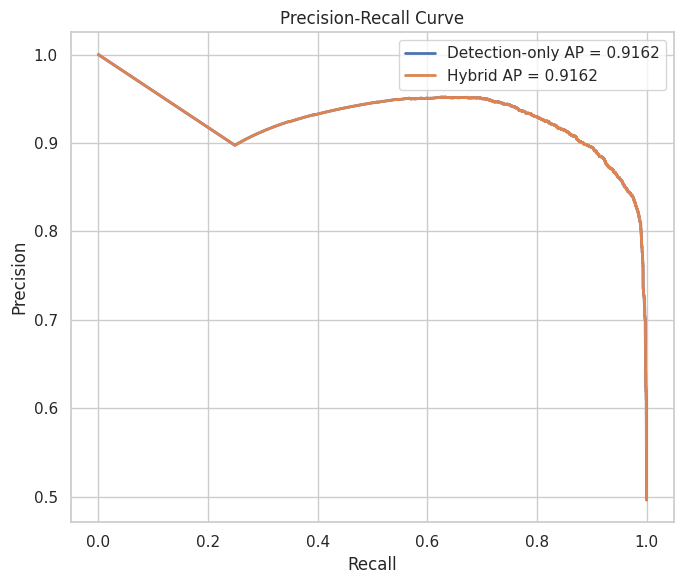


DETECTION vs HYBRID COMPARISON
Detection-only AUC: 0.9530
Hybrid AUC:         0.9530
--------------------------------------
Detection-only AP:  0.9162
Hybrid AP:          0.9162
--------------------------------------
Paired t-test statistic: nan
p-value: nan
Result: No statistically significant difference


In [32]:
# ==============================================
# FINAL ADVANCED ANALYSIS (STABLE VERSION)
# ==============================================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix
)
from scipy.stats import ttest_rel

# Apply seaborn style safely
sns.set_theme(style="whitegrid")


try:
    model_probs
except NameError:
    model_probs = all_probs.copy()



fpr_model, tpr_model, _ = roc_curve(all_labels, model_probs)
auc_model = auc(fpr_model, tpr_model)

fpr_hybrid, tpr_hybrid, _ = roc_curve(all_labels, all_probs)
auc_hybrid = auc(fpr_hybrid, tpr_hybrid)

plt.figure(figsize=(7,6))
plt.plot(fpr_model, tpr_model, linewidth=2, label=f"Detection-only AUC = {auc_model:.4f}")
plt.plot(fpr_hybrid, tpr_hybrid, linewidth=2, label=f"Hybrid AUC = {auc_hybrid:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("roc_comparison.png")
plt.show()




precision_model, recall_model, _ = precision_recall_curve(all_labels, model_probs)
precision_hybrid, recall_hybrid, _ = precision_recall_curve(all_labels, all_probs)

ap_model = average_precision_score(all_labels, model_probs)
ap_hybrid = average_precision_score(all_labels, all_probs)

plt.figure(figsize=(7,6))
plt.plot(recall_model, precision_model, linewidth=2,
         label=f"Detection-only AP = {ap_model:.4f}")
plt.plot(recall_hybrid, precision_hybrid, linewidth=2,
         label=f"Hybrid AP = {ap_hybrid:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.savefig("precision_recall_comparison.png")
plt.show()









t_stat, p_value = ttest_rel(model_probs, all_probs)



print("\n======================================")
print("DETECTION vs HYBRID COMPARISON")
print("======================================")
print(f"Detection-only AUC: {auc_model:.4f}")
print(f"Hybrid AUC:         {auc_hybrid:.4f}")
print("--------------------------------------")
print(f"Detection-only AP:  {ap_model:.4f}")
print(f"Hybrid AP:          {ap_hybrid:.4f}")
print("--------------------------------------")
print(f"Paired t-test statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Statistically significant improvement (p < 0.05)")
else:
    print("Result: No statistically significant difference")



Dataset Training No. 2

In [33]:
import kagglehub

path = kagglehub.dataset_download("kshitizbhargava/deepfake-face-images")

print("Path to dataset files:", path)

100%|██████████| 244M/244M [00:01<00:00, 128MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kshitizbhargava/deepfake-face-images/versions/1


In [ ]:
!cp -r /root/.cache/kagglehub/datasets/kshitizbhargava/deepfake-face-images/versions/1 /content/

In [ ]:
import os
import shutil


target_base = "/content/Dataset"
if os.path.exists(target_base):
    shutil.rmtree(target_base)

if os.path.isdir(os.path.join(path, "Fake")) and os.path.isdir(os.path.join(path, "Real")):
    shutil.copytree(path, target_base)
else:

    found = False
    for root, dirs, files in os.walk(path):
        if "Fake" in dirs and "Real" in dirs:
            shutil.copytree(root, target_base)
            found = True
            break
    if not found:
        raise Exception("Could not find 'Fake' and 'Real' folders in the downloaded dataset. Please check the dataset structure.")

print("Dataset copied to /content/Dataset")
!ls /content/Dataset

In [ ]:
!pip install timm

import os
import json
import hashlib
import random
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
from google.colab import drive

In [ ]:
DATASET_PATH = "/content/Dataset"

print("Contents of dataset root:", os.listdir(DATASET_PATH))
if not os.path.isdir(os.path.join(DATASET_PATH, "Fake")) or not os.path.isdir(os.path.join(DATASET_PATH, "Real")):
    raise Exception("Dataset does not contain 'Fake' and 'Real' folders.")

if not (os.path.isdir(os.path.join(DATASET_PATH, "Train")) and os.path.isdir(os.path.join(DATASET_PATH, "Validation")) and os.path.isdir(os.path.join(DATASET_PATH, "Test"))):
    print("Predefined splits not found. Creating train/val/test splits with 70/15/15 ratio...")

    for split in ["Train", "Validation", "Test"]:
        for label in ["Fake", "Real"]:
            os.makedirs(os.path.join(DATASET_PATH, split, label), exist_ok=True)

    fake_images = [os.path.join(DATASET_PATH, "Fake", f) for f in os.listdir(os.path.join(DATASET_PATH, "Fake")) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    real_images = [os.path.join(DATASET_PATH, "Real", f) for f in os.listdir(os.path.join(DATASET_PATH, "Real")) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    fake_train, fake_temp = train_test_split(fake_images, test_size=0.3, random_state=42)
    fake_val, fake_test = train_test_split(fake_temp, test_size=0.5, random_state=42)

    real_train, real_temp = train_test_split(real_images, test_size=0.3, random_state=42)
    real_val, real_test = train_test_split(real_temp, test_size=0.5, random_state=42)

    for img in fake_train:
        shutil.copy(img, os.path.join(DATASET_PATH, "Train", "Fake", os.path.basename(img)))
    for img in fake_val:
        shutil.copy(img, os.path.join(DATASET_PATH, "Validation", "Fake", os.path.basename(img)))
    for img in fake_test:
        shutil.copy(img, os.path.join(DATASET_PATH, "Test", "Fake", os.path.basename(img)))

    for img in real_train:
        shutil.copy(img, os.path.join(DATASET_PATH, "Train", "Real", os.path.basename(img)))
    for img in real_val:
        shutil.copy(img, os.path.join(DATASET_PATH, "Validation", "Real", os.path.basename(img)))
    for img in real_test:
        shutil.copy(img, os.path.join(DATASET_PATH, "Test", "Real", os.path.basename(img)))

    print("Splits created successfully.")
else:
    print("Using existing train/val/test splits.")

In [ ]:
def compute_hash(file_path):
    with open(file_path, "rb") as f:
        return hashlib.sha256(f.read()).hexdigest()

def generate_metadata(image_path):
    metadata = {
        "hash": compute_hash(image_path),
        "timestamp": datetime.now().isoformat(),
        "device_id": hashlib.sha256(b"device_01").hexdigest()[:16]
    }
    with open(image_path + ".json", "w") as f:
        json.dump(metadata, f)

for split in ["Train", "Validation", "Test"]:
    for label in ["Fake", "Real"]:
        folder = os.path.join(DATASET_PATH, split, label)
        for file in os.listdir(folder):
            if file.lower().endswith((".jpg", ".png", ".jpeg")):
                generate_metadata(os.path.join(folder, file))

print("Provenance metadata created.")

In [ ]:
def remove_random_metadata(folder, percentage=0.2):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    remove_count = int(len(files) * percentage)
    for f in random.sample(files, remove_count):
        os.remove(os.path.join(folder, f))

def forge_random_metadata(folder, percentage=0.1):
    files = [f for f in os.listdir(folder) if f.endswith(".json")]
    forge_count = int(len(files) * percentage)
    for f in random.sample(files, forge_count):
        path = os.path.join(folder, f)
        with open(path, "r") as file:
            metadata = json.load(file)
        metadata["hash"] = "FORGED_HASH"
        with open(path, "w") as file:
            json.dump(metadata, file)

for label in ["Fake", "Real"]:
    folder = os.path.join(DATASET_PATH, "Test", label)
    remove_random_metadata(folder, 0.2)
    forge_random_metadata(folder, 0.1)

print("Provenance manipulation simulated.")

In [ ]:
def verify_provenance(image_path):
    metadata_path = image_path + ".json"

    if not os.path.exists(metadata_path):
        return "missing"

    with open(metadata_path, "r") as f:
        metadata = json.load(f)

    if metadata["hash"] != compute_hash(image_path):
        return "forged"

    return "valid"

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 2

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, "Train"), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, "Validation"), transform=transform)
test_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, "Test"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model('efficientnet_b0', pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
from tqdm import tqdm

EPOCHS = 6

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(loss=loss.item())

    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

In [ ]:
model.eval()

all_probs = []
all_labels = []
all_preds = []
all_paths = []

with torch.no_grad():
    for i, (images, labels) in enumerate(test_loader):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:,1]

        for j in range(len(probs)):
            idx = i * BATCH_SIZE + j
            image_path = test_dataset.samples[idx][0]

            provenance_status = verify_provenance(image_path)
            model_score = probs[j].item()

            if provenance_status == "valid":
                adjustment = 0
            elif provenance_status == "missing":
                adjustment = 0.15
            elif provenance_status == "forged":
                adjustment = 0.35

            final_score = min(model_score + adjustment, 1.0)
            prediction = 1 if final_score > 0.5 else 0

            all_probs.append(final_score)
            all_labels.append(labels[j].item())
            all_preds.append(prediction)
            all_paths.append(image_path)

In [ ]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

In [ ]:
report = classification_report(all_labels, all_preds, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report.to_csv("classification_report.csv")
df_report

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
df_cm = pd.DataFrame(cm,
                     columns=["Pred Real", "Pred Fake"],
                     index=["Actual Real", "Actual Fake"])
df_cm.to_csv("confusion_matrix.csv")
df_cm

In [ ]:
results_df = pd.DataFrame({
    "Image_Path": all_paths,
    "True_Label": all_labels,
    "Predicted_Label": all_preds,
    "Hybrid_Score": all_probs
})

results_df.to_csv("detailed_results.csv")
results_df.head()

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

sns.set_theme(style="whitegrid")


cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix_visual.png", dpi=300)
plt.show()




fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_visual.png", dpi=300)
plt.show()




real_scores = [all_probs[i] for i in range(len(all_labels)) if all_labels[i] == 0]
fake_scores = [all_probs[i] for i in range(len(all_labels)) if all_labels[i] == 1]

plt.figure(figsize=(7,5))
sns.histplot(real_scores, color="green", label="Real", kde=True, stat="density", bins=30)
sns.histplot(fake_scores, color="red", label="Fake", kde=True, stat="density", bins=30)
plt.legend()
plt.title("Hybrid Score Distribution")
plt.xlabel("Hybrid Score")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig("score_distribution.png", dpi=300)
plt.show()




plt.figure(figsize=(6,5))
sns.boxplot(data=[real_scores, fake_scores])
plt.xticks([0,1], ["Real", "Fake"])
plt.title("Hybrid Score Comparison")
plt.ylabel("Score")
plt.tight_layout()
plt.savefig("score_boxplot.png", dpi=300)
plt.show()




accuracy = np.mean(np.array(all_labels) == np.array(all_preds))

print("\n====================================")
print("FINAL PERFORMANCE SUMMARY")
print("====================================")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC Score: {roc_auc:.4f}")
print(f"Total Samples: {len(all_labels)}")
print("====================================")



In [ ]:


import os
import json
import random
import time
import io
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import timm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, auc
from PIL import Image, ImageFilter
import imagehash

print("=== Starting Unified Social IoT Provenance Pipeline ===\n")

DATASET_PATH = "/content/Dataset"
TEMP_PATH = "/content/temp_eval"
os.makedirs(TEMP_PATH, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = timm.create_model('efficientnet_b0', pretrained=True)
model.classifier = nn.Linear(model.classifier.in_features, 2)
model = model.to(device)
model.eval()

BATCH_SIZE = 2
IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(os.path.join(DATASET_PATH, "Test"), transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def generate_metadata():
    print("Checking/Generating metadata...")
    count = 0
    for path, _ in test_dataset.samples:
        json_path = path + ".json"
        if not os.path.exists(json_path):
            img = Image.open(path).convert("RGB")
            ph = str(imagehash.phash(img))
            with open(json_path, "w") as f:
                json.dump({"phash": ph}, f)
            count += 1
    print(f"Metadata generated for {count} images\n")

def compute_phash(image_path):
    return str(imagehash.phash(Image.open(image_path)))

def hamming_distance(h1, h2):
    return imagehash.hex_to_hash(h1) - imagehash.hex_to_hash(h2)

def verify_provenance(image_path):
    metadata_path = image_path + ".json"
    if not os.path.exists(metadata_path):
        return "missing"

    with open(metadata_path, "r") as f:
        metadata = json.load(f)

    original_hash = metadata.get("phash")
    if original_hash is None:
        return "missing"

    current_hash = compute_phash(image_path)
    dist = hamming_distance(original_hash, current_hash)

    if dist <= 10:
        return "valid"
    else:
        return "forged"

def provenance_score(image_path):
    metadata_path = image_path + ".json"
    if not os.path.exists(metadata_path):
        return 0.5

    with open(metadata_path, "r") as f:
        metadata = json.load(f)

    original_hash = metadata.get("phash")
    if original_hash is None:
        return 0.5

    current_hash = compute_phash(image_path)
    dist = hamming_distance(original_hash, current_hash)

    return min(dist / 20.0, 1.0)

def apply_social_iot_transforms(img):
    img = img.copy()

    if random.random() > 0.4:
        img = transforms.functional.resize(img, random.choice([512, 720, 1080]))

    buffer = io.BytesIO()
    img.save(buffer, format="JPEG", quality=random.randint(70, 90))
    img = Image.open(buffer)

    if random.random() > 0.5:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.2, 0.6)))

    return img

def evaluate_provenance_survivability(n_transforms=3, runs=5):
    print(f"Evaluating provenance survivability ({n_transforms} transformations, {runs} runs)...")
    results = []

    for run in range(runs):
        survived = 0
        total = 0

        for i, (path, _) in enumerate(test_dataset.samples):
            if verify_provenance(path) == "missing":
                continue

            total += 1

            temp_img = os.path.join(TEMP_PATH, f"temp_{run}_{i}.jpg")
            temp_json = temp_img + ".json"

            shutil.copy(path, temp_img)
            shutil.copy(path + ".json", temp_json)

            img = Image.open(temp_img).convert("RGB")

            for _ in range(n_transforms):
                img = apply_social_iot_transforms(img)

                rand = random.random()
                if rand < 0.3:
                    if os.path.exists(temp_json):
                        os.remove(temp_json)
                elif rand < 0.5:
                    fake_hash = str(imagehash.phash(img))
                    with open(temp_json, "w") as f:
                        json.dump({"phash": fake_hash}, f)

            img.save(temp_img)

            if verify_provenance(temp_img) == "valid":
                survived += 1

        rate = (survived / total * 100) if total > 0 else 0

        results.append({
            'run': run,
            'survival_rate_%': round(rate, 2),
            'n_transforms': n_transforms
        })

    df = pd.DataFrame(results)
    print(df)
    df.to_csv("/content/provenance_survivability.csv", index=False)

    print(f"Average Survivability Rate: {df['survival_rate_%'].mean():.2f}%\n")
    return df


generate_metadata()

print("1. Running Provenance Survivability Analysis...")
surv_df = evaluate_provenance_survivability()

print("\n2. Running Ablation Study on Penalty Values...")

ablation_results = []

for miss in [0.05, 0.1, 0.15, 0.2, 0.25]:
    for forge in [0.25, 0.3, 0.35, 0.4, 0.45]:

        all_det, all_hyb, all_labels = [], [], []

        with torch.no_grad():
            for i, (images, labels) in enumerate(test_loader):
                images = images.to(device)
                outputs = model(images)
                probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()

                for j in range(len(probs)):
                    idx = i * BATCH_SIZE + j
                    path = test_dataset.samples[idx][0]

                    det = float(probs[j])
                    prov = provenance_score(path)
                    status = verify_provenance(path)

                    if status == "missing":
                        prov = min(prov + miss, 1.0)
                    elif status == "forged":
                        prov = min(prov + forge, 1.0)

                    hyb = min(0.7 * det + 0.3 * prov, 1.0)

                    all_det.append(det)
                    all_hyb.append(hyb)
                    all_labels.append(labels[j].item())

        fpr_d, tpr_d, _ = roc_curve(all_labels, all_det)
        fpr_h, tpr_h, _ = roc_curve(all_labels, all_hyb)

        auc_d = auc(fpr_d, tpr_d)
        auc_h = auc(fpr_h, tpr_h)

        print(f"Penalty miss={miss}, forge={forge} → "
              f"AUC Det: {auc_d:.4f} | Hyb: {auc_h:.4f} | Gain: {auc_h-auc_d:.4f}")

        ablation_results.append({
            'penalty_missing': miss,
            'penalty_forged': forge,
            'AUC_detection': auc_d,
            'AUC_hybrid': auc_h,
            'Gain': auc_h - auc_d
        })

ablation_df = pd.DataFrame(ablation_results)
ablation_df.to_csv("/content/ablation_results.csv", index=False)

print("\nAblation Summary (mean across penalties):")
print(ablation_df.groupby(['penalty_missing', 'penalty_forged']).mean()[['AUC_detection', 'AUC_hybrid', 'Gain']])

print("\n3. Computational Overhead Analysis")

times = []
dummy = next(iter(test_loader))[0].to(device)

for _ in range(30):
    start = time.time()
    _ = model(dummy)
    times.append(time.time() - start)

print(f"Inference time: {np.mean(times)*1000:.2f} ms per image")
print(f"Std: {np.std(times)*1000:.2f} ms")
print(f"Model parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")

print("\n4. Privacy Analysis")
print("Current metadata schema exposes:")
print("• Perceptual hash (image fingerprint)")
print("Recommendation: Add encryption + avoid linking to user identity.")

print("\n=== PIPELINE COMPLETED SUCCESSFULLY ===")
print("Generated files ready for Chapter 5:")
print("provenance_survivability.csv")
print("ablation_results.csv")

print("\nYou can now create tables for:")
print("- Provenance Survivability under Social IoT Transformations")
print("- Ablation Study: Penalty Sensitivity Analysis")
print("- Computational Overhead")
print("- Hybrid vs Detection-only Performance")

print("\nReady for writing Results & Analysis section.")


#Grad-CAM Visualization


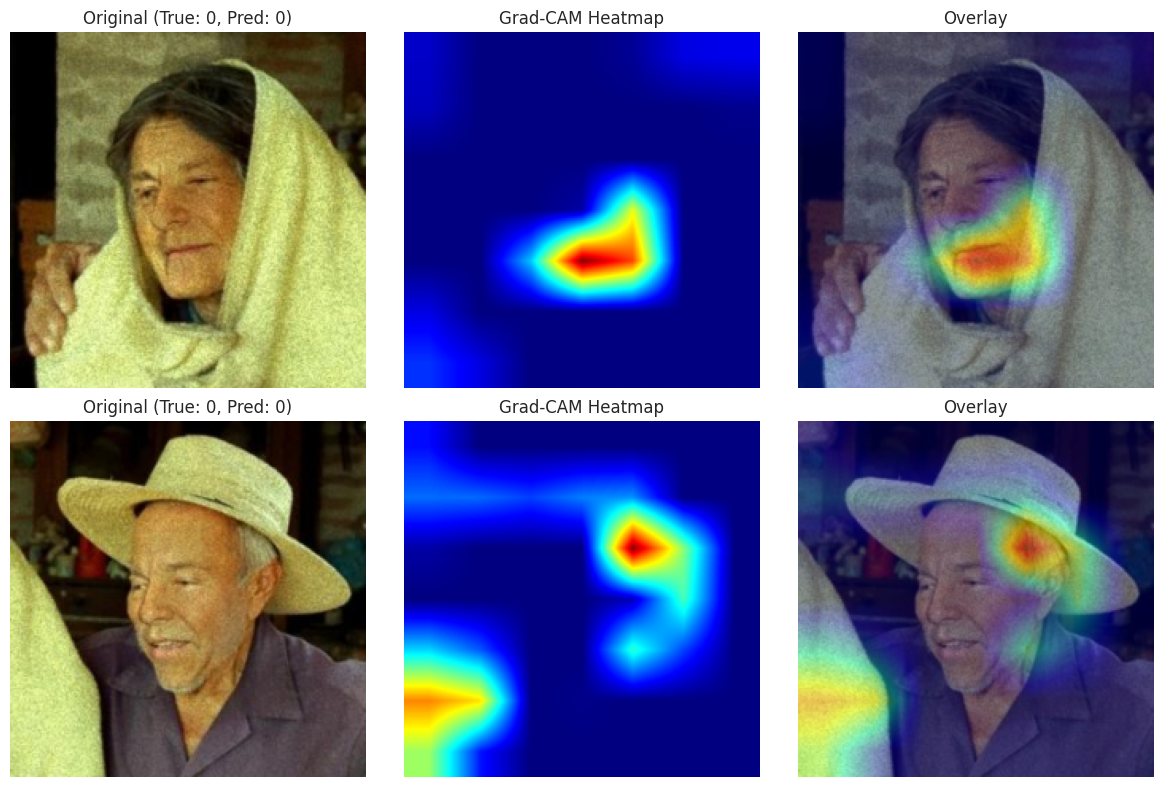

In [36]:
# %% [markdown]
# ## Grad-CAM Visualization (Fixed)
# Run this cell after training to see which regions the model focuses on.

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision.transforms import Compose, Normalize
from PIL import Image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles()

    def hook_handles(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        self.forward_handle = self.target_layer.register_forward_hook(forward_hook)
        self.backward_handle = self.target_layer.register_full_backward_hook(backward_hook)

    def remove_handles(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

    def __call__(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        gradients = self.gradients[0]      # (C, H, W) on GPU
        activations = self.activations[0]  # (C, H, W) on GPU
        weights = gradients.mean(dim=(1,2)) # (C,) on GPU

        # Ensure cam is on the same device as activations
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32, device=activations.device)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam = cam - cam.min()
        if cam.max() != 0:
            cam = cam / cam.max()
        return cam.cpu().numpy()  # move to CPU for visualization

# Inverse normalization for displaying the image
inv_normalize = Compose([
    Normalize(mean=[0,0,0], std=[1/0.229, 1/0.224, 1/0.225]),
    Normalize(mean=[-0.485, -0.456, -0.406], std=[1,1,1])
])

def denorm(tensor):
    img = inv_normalize(tensor.squeeze(0).cpu()).clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

# Target the last convolutional layer of EfficientNet‑B0
target_layer = model.conv_head
gradcam = GradCAM(model, target_layer)

# Get a few test images (first batch)
test_iter = iter(test_loader)
images, labels = next(test_iter)

fig, axes = plt.subplots(min(4, images.size(0)), 3, figsize=(12, 4 * min(4, images.size(0))))
if min(4, images.size(0)) == 1:
    axes = np.expand_dims(axes, axis=0)

for i in range(min(4, images.size(0))):
    img_tensor = images[i].unsqueeze(0).to(device)
    pred = model(img_tensor).argmax(dim=1).item()
    cam = gradcam(img_tensor, class_idx=pred)

    # Resize cam to image size
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    original = denorm(images[i])
    overlay = 0.6 * original + 0.4 * heatmap
    overlay = np.clip(overlay, 0, 1)

    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f"Original (True: {labels[i].item()}, Pred: {pred})")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(heatmap)
    axes[i, 1].set_title("Grad‑CAM Heatmap")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title("Overlay")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig("gradcam_examples.png", dpi=300)
plt.show()

# Clean up hooks
gradcam.remove_handles()